In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6582, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda')

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

# 5. Contribution Layer Drop

In [34]:
from layer_drop import layer_drop

In [35]:
from layer_merge_helper import reorder_merged_layer_heads, reorder_merged_layer_neurons

In [36]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [37]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)
  Layer 6: Registered masks (12 heads, 3072 neurons)
  Layer 7: Registered masks (12 heads, 3072 neurons)
  Layer 8: Registered masks (12 heads, 3072 neurons)
  Layer 9: Registered masks (12 heads, 3072 neurons)
  Layer 10: Registered masks (12 heads, 3072 neurons)
  Layer 11: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [39]:
init_metric = eval_loop(model, val_dataloader, task_name, device)[0]
init_metric

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [40]:
performance_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="contribution_merge"
)

Target Metric for mrpc: f1
Original f1 score: 0.9094
Recovery threshold: 0.0091

Merge Iteration: 1/9


CKA Evaluation: 100%|██████████| 115/115 [01:21<00:00,  1.41it/s]


  Similarity Stats:
    Average: 0.899861
    Highest: 0.993713
    Lowest:  0.724249
Drop Layer: 9


Computing importance (heads + FFN): 100%|██████████| 115/115 [00:36<00:00,  3.14it/s]


10 6
2403 1693
Number of Layers Remaining: 11
  Metrics:
      accuracy: 0.8750
    ★ f1: 0.9122
  Performance drop: -0.0028 (threshold: 0.0091)
  → Recovery training NOT needed
  • 11 layers (not in target list, skipping save)
Merge Iteration: 2/9


...

✓ Saved checkpoint (best loss: 1.1499)

<----------------- Epoch 1 ----------------->
Loss: 0.49, Training Metrics:
  accuracy: 0.9444
  f1: 0.9590
Validation Loss: 1.15, Validation Metrics:
  accuracy: 0.8186
  f1: 0.8795
Elapsed Time: 33.0185 sec


Training:  20%|██        | 230/1150 [01:14<04:31,  3.39it/s]  


<----------------- Epoch 2 ----------------->
Loss: 0.2, Training Metrics:
  accuracy: 0.9776
  f1: 0.9835
Validation Loss: 1.29, Validation Metrics:
  accuracy: 0.8162
  f1: 0.8780
Elapsed Time: 33.1196 sec


Training:  23%|██▎       | 259/1150 [01:24<03:53,  3.82it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 78.00 MiB. GPU 0 has a total capacity of 47.40 GiB of which 75.75 MiB is free. Process 2270220 has 297.60 MiB memory in use. Process 2366194 has 18.40 GiB memory in use. Process 2948946 has 4.42 GiB memory in use. Process 3193748 has 3.74 GiB memory in use. Process 3287404 has 10.15 GiB memory in use. Including non-PyTorch memory, this process has 10.15 GiB memory in use. Of the allocated memory 8.29 GiB is allocated by PyTorch, and 1.55 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [38]:
performance_track

{'performance_track': [{'accuracy': 0.8676470588235294,
   'f1': 0.9093959731543624},
  {'accuracy': 0.8799019607843137, 'f1': 0.9141856392294221},
  {'accuracy': 0.8700980392156863, 'f1': 0.9100169779286927},
  {'accuracy': 0.8578431372549019, 'f1': 0.8996539792387543},
  {'accuracy': 0.8504901960784313, 'f1': 0.8981636060100167},
  {'accuracy': 0.8651960784313726, 'f1': 0.905982905982906},
  {'accuracy': 0.8088235294117647, 'f1': 0.8733766233766234},
  {'accuracy': 0.7794117647058824, 'f1': 0.8514851485148515},
  {'accuracy': 0.6862745098039216, 'f1': 0.7968253968253968},
  {'accuracy': 0.6911764705882353, 'f1': 0.7980769230769231}],
 'remaining_layers': [[0, 6, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 10, 11],
  [0, 2, 3, 4, 5, 6, 7, 10, 11],
  [0, 2, 3, 4, 5, 6, 10, 11],
  [0, 2, 3, 4, 5, 6, 11],
  [0, 3, 4, 5, 6, 11],
  [0, 4, 5, 6, 11],
  [0, 5, 6, 11],
  [0, 6, 11]]}

In [39]:
torch.save(performance_track, f'./weights/contribution_merge/performance_track_{task_name}.pt')

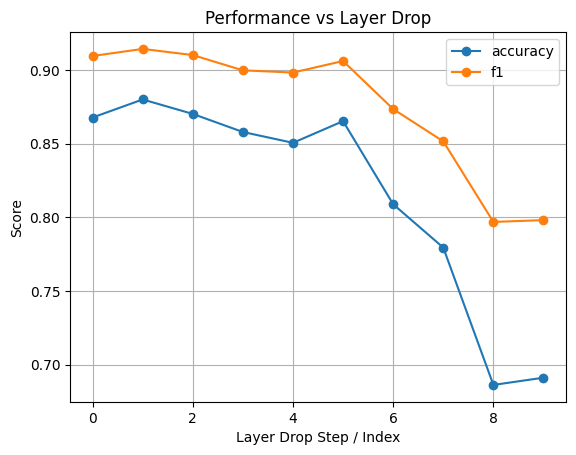

In [40]:
import matplotlib.pyplot as plt

performance_track = performance_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()